In [1]:
import healpy as hp
import numpy as np
from astropy.io import fits
import matplotlib.pyplot as plt
from astropy.wcs import WCS

filepath = "data/dirk_healpix_02.fits"

# 1. Header 信息
with fits.open(filepath) as hdul:
    print("HDU 列表：")
    hdul.info()
    header = hdul[1].header
    cols = hdul[1].columns

# 中文注释：从列名解析频率（单位 MHz）
Freqs101 = []

for col in cols:
    name = col.name  # 例如 'F950.000MHz'
    freq = float(name.replace("F", "").replace("MHz", "")) # 去掉前缀 F 和后缀 MHz
    Freqs101.append(freq)

Freqs101 = np.array(Freqs101)
print("频率范围:", Freqs101.min(), "-", Freqs101.max(), "MHz")
print("通道数:", len(Freqs101))

HDU 列表：
Filename: data/dirk_healpix_02.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU       4   ()      
  1  xtension      1 BinTableHDU    320   786432R x 101C   [D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D]   
频率范围: 950.0 - 1050.0 MHz
通道数: 101


In [2]:
# 读取 HEALPix 地图（多层）
Healpix_maps = hp.read_map(filepath, field=None)   # 多 field → shape: (nmap, npix)

nmap, npix = Healpix_maps.shape
nside = hp.get_nside(Healpix_maps[7]) # 随便选一个频率处的

print("\n=== 基本参数 ===")
print(f"NSIDE = {nside}")
print(f"NPIX  = {npix}")
print(f"层数 nmap = {nmap}")
print(f"理论像素数 = {hp.nside2npix(nside)}")

if npix != hp.nside2npix(nside):
    print("⚠️ 像素数不匹配")
else:
    print("✔️ 像素数匹配")


=== 基本参数 ===
NSIDE = 256
NPIX  = 786432
层数 nmap = 101
理论像素数 = 786432
✔️ 像素数匹配


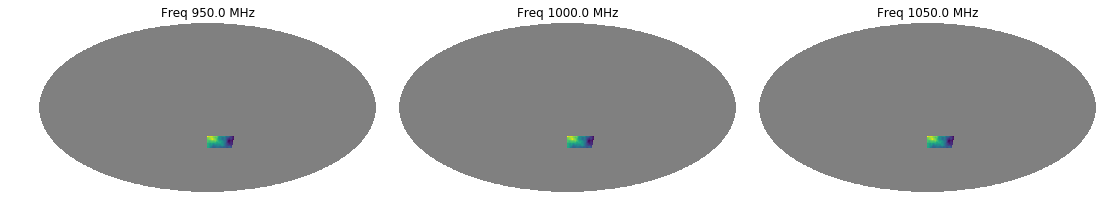

In [3]:
# 画出healpix天图
plt.figure(figsize=(15, 4))
for i, idx in enumerate([0, 50, 100]):
    hp.mollview(
        Healpix_maps[idx],
        title=f"Freq {Freqs101[idx]:.1f} MHz",
        sub=(1, 3, i + 1),   # (行, 列, 位置)
        cbar=False)
plt.show()

In [4]:
# 分辨率
resol = hp.nside2resol(nside, arcmin=True)
print(f"\n角分辨率 ~ {resol:.2f} arcmin")


角分辨率 ~ 13.74 arcmin
